#### NX-414: Brain-like computation and intelligence
Notebook prepared by Alessandro Marin Vargas

# Week 8 - Mini projects (Predicting neural activity)

The objectives of the mini project are:
- Learn how to predict neural activity using linear regression from images and from neural network layers.
- Quantify the goodness of the model
- Compare the results across the network layers and between trained/random neural network
- Predict the neural activity using a neural network in a data-driven approach

Specifically, here you will use the data from the following [paper](https://www.jneurosci.org/content/jneuro/35/39/13402.full.pdf). The behavioral experiment consisted in showing to non-human primates some images while recording the neural activity with multielectrode arrays from the inferior temporal (IT) cortex. Here, the neural activity and the images are already pre-processed and you will have available the images and the corresponding average firing rate (between 70 and 170 ms) per each neuron.

In [1]:
import sys
sys.path.append('./../')
!{sys.executable} -m pip install gdown h5py

You should consider upgrading via the '/home/vvoigt/Documents/NX/NX-414-Project/venv/bin/python -m pip install --upgrade pip' command.


In [2]:
import utils
import matplotlib.pyplot as plt
import numpy as np
import gdown
url = "https://drive.google.com/file/d/1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS/view?usp=share_link"
output = "IT_data.h5"
gdown.download(url, output, quiet=False, fuzzy=True)


Downloading...
From (original): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS
From (redirected): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS&confirm=t&uuid=c68afdc3-31d8-4383-9424-25dc037c609e
To: /home/vvoigt/IT_data.h5
100%|████████████████████████████████████████████████████████████████████████████████████████████| 384M/384M [00:02<00:00, 161MB/s]


'IT_data.h5'

### Load the data

In [3]:
###copy pasted from utils, since import did somehow not work...
import h5py
import os

import matplotlib.pyplot as plt
import numpy as np
def load_it_data(path_to_data):
    """ Load IT data

    Args:
        path_to_data (str): Path to the data

    Returns:
        np.array (x6): Stimulus train/val/test; objects list train/val/test; spikes train/val
    """

    datafile = h5py.File(os.path.join(path_to_data,'IT_data.h5'), 'r')

    stimulus_train = datafile['stimulus_train'][()]
    spikes_train = datafile['spikes_train'][()]
    objects_train = datafile['object_train'][()]
    
    stimulus_val = datafile['stimulus_val'][()]
    spikes_val = datafile['spikes_val'][()]
    objects_val = datafile['object_val'][()]
    
    stimulus_test = datafile['stimulus_test'][()]
    objects_test = datafile['object_test'][()]

    ### Decode back object type to latin
    objects_train = [obj_tmp.decode("latin-1") for obj_tmp in objects_train]
    objects_val = [obj_tmp.decode("latin-1") for obj_tmp in objects_val]
    objects_test = [obj_tmp.decode("latin-1") for obj_tmp in objects_test]

    return stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val


def visualize_img(stimulus,objects,stim_idx):
    """Visualize image given the stimulus and corresponding index and the object name.

    Args:
        stimulus (array of float): Stimulus containing all the images
        objects (list of str): Object list containing all the names
        stim_idx (int): Index of the stimulus to plot
    """    
    normalize_mean=[0.485, 0.456, 0.406]
    normalize_std=[0.229, 0.224, 0.225]

    img_tmp = np.transpose(stimulus[stim_idx],[1,2,0])

    ### Go back from normalization
    img_tmp = (img_tmp*normalize_std + normalize_mean) * 255

    plt.figure()
    plt.imshow(img_tmp.astype(np.uint8),cmap='gray')
    plt.title(str(objects[stim_idx]))
    plt.show()
    return

In [4]:
path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


In [5]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
_, n_neurons = spikes_train.shape
print('The dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

The dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


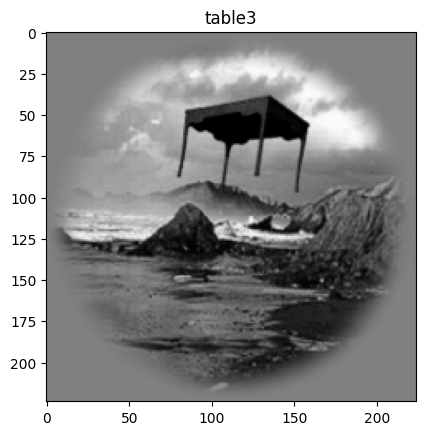

In [6]:
stim_idx = 1

visualize_img(stimulus_train,objects_train,stim_idx)

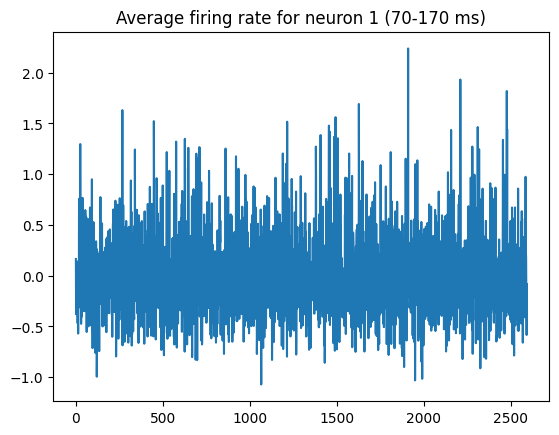

In [7]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])

# Challenge: Develop the most accurate model for predicting IT neural activity.

Throughout the mini-projects, you have acquired knowledge on predicting neural activity through both task-driven and data-driven approaches. You are now free to explore both approaches to create the most effective model for predicting neural activity. Here are some suggestions to help guide your exploration:
- Optimize your current models by adjusting hyperparameters and implementing different regularizations.
- Utilize different pretrained models.
- Employ a pretrained neural network and finetune it for predicting the neural activity.
- Train a neural network for object recognition while simultaneously predicting neural activity.
- ...

Please note that all models will be tested using the same type of linear regression.

### EVALUATION

You have until midnight of 07/05/25 to submit your mini-projects. Please upload a .zip file on Moodle containing your code and, specifically, the following:

- A one-page report (Report.pdf) detailing your investigation, including figures and model comparisons.
- A script (test.py) or notebook (test.ipynb) in which you show an example of your best model's usage. Please include instructions on loading the model and making neural predictions on the validation set. If necessary, include the checkpoint of your model in the .zip file.

Best of luck!

In [8]:
### Here your code

### First approach: using a pretrained model, namely VGG16

In [9]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr
from tqdm import tqdm

In [10]:
from torchvision import transforms
import torch

# Convert numpy arrays to torch tensors
stimulus_train_torch = torch.tensor(stimulus_train).float()
stimulus_val_torch = torch.tensor(stimulus_val).float()

# Define normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Apply normalization
stim_train_torch = torch.stack([normalize(img) for img in stimulus_train_torch])
stim_val_torch = torch.stack([normalize(img) for img in stimulus_val_torch])

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader, TensorDataset

# Define the model (fine-tuning VGG16)
class VGG16_Finetune(nn.Module):
    def __init__(self, pretrained_model):
        super(VGG16_Finetune, self).__init__()
        # Take all layers except the classifier (final fully connected layers)
        self.features = pretrained_model.features
        # Replace the classifier to output the neural activity (number of neurons to predict)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),  # VGG16 has a 512 * 7 * 7 output from the convolutional layers
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, spikes_train.shape[1])  # Number of neurons (based on spikes_train)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # Flatten the output to pass it into the fully connected layers
        x = self.classifier(x)
        return x

# Load the pretrained VGG16 model
vgg16_model = models.vgg16(pretrained=True)

# Fine-tune the model (we'll modify the classifier part)
model_finetuned = VGG16_Finetune(vgg16_model)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_finetuned.to(device)

# DataLoader: Convert data to tensors and create DataLoader for batching
def create_dataloader(stimulus, spikes, batch_size):
    # Convert to TensorDataset and DataLoader for batching
    dataset = TensorDataset(stimulus, spikes)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

# Define batch size (adjust this based on GPU memory)
batch_size_train = 64  # For training
batch_size_val = 32    # For validation (can be smaller for evaluation)

# Convert your stimuli and spikes to tensors (if not already)
stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)

# Create dataloaders
train_dataloader = create_dataloader(stimulus_train_tensor, spikes_train_tensor, batch_size_train)
val_dataloader = create_dataloader(stimulus_val_tensor, spikes_val_tensor, batch_size_val)

# Define the loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.Adam(model_finetuned.parameters(), lr=1e-4)  # Adam optimizer

/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
# Number of epochs to train
num_epochs = 10

# Training loop
for epoch in range(num_epochs):
    model_finetuned.train()  # Set the model to training mode
    running_loss = 0.0
    for batch_input, batch_labels in train_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)

        optimizer.zero_grad()  # Zero the gradients
        outputs = model_finetuned(batch_input)  # Forward pass
        loss = criterion(outputs, batch_labels)  # Compute the loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update the weights

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_dataloader):.4f}")


Epoch [1/10], Loss: 0.1288
Epoch [2/10], Loss: 0.0995
Epoch [3/10], Loss: 0.0829
Epoch [4/10], Loss: 0.0711
Epoch [5/10], Loss: 0.0612
Epoch [6/10], Loss: 0.0518
Epoch [7/10], Loss: 0.0439
Epoch [8/10], Loss: 0.0385
Epoch [9/10], Loss: 0.0336
Epoch [10/10], Loss: 0.0300


In [13]:
# Evaluate the model on the validation set
model_finetuned.eval()  # Set the model to evaluation mode
with torch.no_grad():
    val_outputs = []
    val_labels = []
    for batch_input, batch_labels in val_dataloader:
        batch_input, batch_labels = batch_input.to(device), batch_labels.to(device)
        outputs = model_finetuned(batch_input)
        val_outputs.append(outputs.cpu().numpy())
        val_labels.append(batch_labels.cpu().numpy())

    val_outputs = np.concatenate(val_outputs, axis=0)
    val_labels = np.concatenate(val_labels, axis=0)

    # Compute Pearson Correlation
    pearson_corr = np.corrcoef(val_outputs.flatten(), val_labels.flatten())[0, 1]
    print(f"Pearson Correlation: {pearson_corr:.4f}")

    # Compute Explained Variance Score
    evs = explained_variance_score(val_labels, val_outputs)
    print(f"Explained Variance Score: {evs:.4f}")

Pearson Correlation: 0.6959
Explained Variance Score: 0.4075


make plot for variation of neural prediction across layers.

In [89]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook


conv_layer_indices = {
    "conv1_1": 0, "conv1_2": 2,
    "conv2_1": 5, "conv2_2": 7,
    "conv3_1": 10, "conv3_2": 12, "conv3_3": 14,
    "conv4_1": 17, "conv4_2": 19, "conv4_3": 21,
    "conv5_1": 24, "conv5_2": 26, "conv5_3": 28,
}

layer_names = list(conv_layer_indices.keys())

for name, idx in conv_layer_indices.items():
    model_finetuned.features[idx].register_forward_hook(get_activation(name))



In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import explained_variance_score
import numpy as np
import torch
from sklearn.linear_model import Ridge


model_finetuned.eval()

features_val = {name: [] for name in layer_names}
features_train = {name: [] for name in layer_names}
targets_val = []
targets_train = []

# TRAIN
activations = {}

for images, spike_targets in train_dataloader:
    with torch.no_grad():
        images = images.to(device)
        spike_targets = spike_targets.to(device)
        _ = model_finetuned(images)

        for name in layer_names:
            act = activations[name]  # shape: (B, C, H, W)
            pooled = torch.nn.functional.adaptive_avg_pool2d(act, (4, 4))  # (B, C, 4, 4)
            flat = pooled.view(act.size(0), -1)  # (B, C * 4 * 4)
            features_train[name].append(flat.cpu())

        targets_train.append(spike_targets.cpu())

# VAL
for images, spike_targets in val_dataloader:
    with torch.no_grad():
        images = images.to(device)
        spike_targets = spike_targets.to(device)
        _ = model_finetuned(images)

        for name in layer_names:
            act = activations[name]
            pooled = torch.nn.functional.adaptive_avg_pool2d(act, (4, 4))  # Add this line
            flat = pooled.view(act.size(0), -1)                            # Same as in training
            features_val[name].append(flat.cpu())

        targets_val.append(spike_targets.cpu())

# Finalize
for name in layer_names:
    features_train[name] = torch.cat(features_train[name]).numpy()
    features_val[name] = torch.cat(features_val[name]).numpy()
targets_train = torch.cat(targets_train).numpy()
targets_val = torch.cat(targets_val).numpy()

# Evaluate
r2_scores = []
pearson_rs = []

for name in layer_names:
    X_train = features_train[name]
    X_val = features_val[name]
    
    from sklearn.decomposition import PCA
    pca = PCA(n_components=100).fit(X_train)
    X_train = pca.transform(X_train)
    X_val = pca.transform(X_val)

    reg = Ridge(alpha=1.0)
    reg.fit(X_train, targets_train)

    preds = reg.predict(X_val)
    r2 = explained_variance_score(targets_val, preds)
    corr = np.corrcoef(targets_val.ravel(), preds.ravel())[0, 1]
    
    r2_scores.append(r2)
    pearson_rs.append(corr)

    print(f"{name}: R² = {r2:.3f}, Pearson r = {corr:.3f}")


conv1_1: R² = 0.167, Pearson r = 0.442
conv1_2: R² = 0.202, Pearson r = 0.480
conv2_1: R² = 0.242, Pearson r = 0.527
conv2_2: R² = 0.263, Pearson r = 0.546
conv3_1: R² = 0.269, Pearson r = 0.553
conv3_2: R² = 0.293, Pearson r = 0.574
conv3_3: R² = 0.330, Pearson r = 0.615
conv4_1: R² = 0.356, Pearson r = 0.640
conv4_2: R² = 0.364, Pearson r = 0.649
conv4_3: R² = 0.383, Pearson r = 0.664
conv5_1: R² = 0.385, Pearson r = 0.667
conv5_2: R² = 0.386, Pearson r = 0.670
conv5_3: R² = 0.393, Pearson r = 0.676


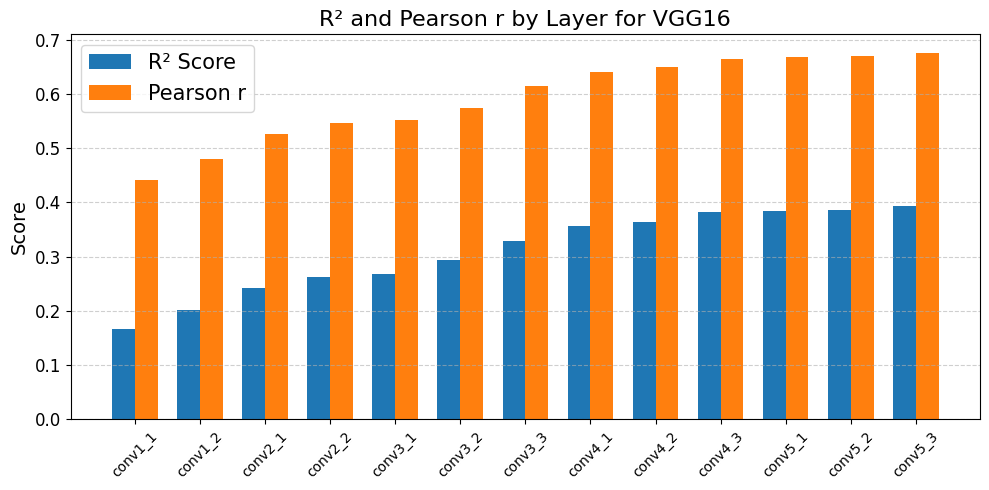

In [91]:
# Plot
x = np.arange(len(layer_names))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 5))
bar1 = ax1.bar(x - width/2, r2_scores, width, label='R² Score')
bar2 = ax1.bar(x + width/2, pearson_rs, width, label='Pearson r')


# Set axis labels and title with larger font size
ax1.set_ylabel('Score', fontsize=14)
ax1.set_title('R² and Pearson r by Layer for VGG16', fontsize=16)

# Set x-ticks and labels with larger font size
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names, rotation=45, fontsize=12)

# Use tick_params to set font size for the ticks
ax1.tick_params(axis='x', labelsize=10)  # Adjust the x-tick label font size
ax1.tick_params(axis='y', labelsize=12) 

# Set legend with larger font size
ax1.legend(fontsize=15)

# Layout adjustments and grid
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Save the figure with high DPI
plt.savefig("variation_across_layers.png", dpi=300)

# Show the plot
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2216995].


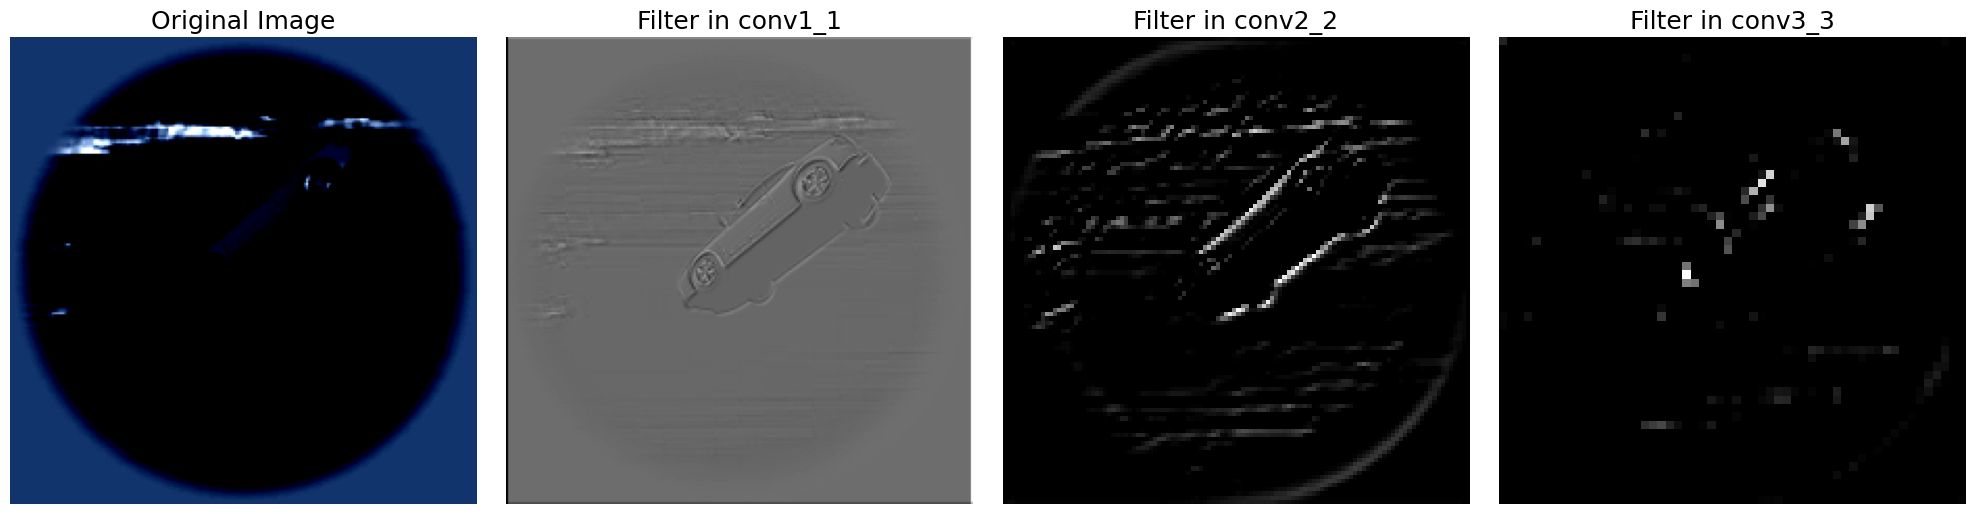

In [92]:
import matplotlib.pyplot as plt

# Assuming 'activations' is already populated with the activation outputs
layer_names_plt2 = ['conv1_1', 'conv2_2', 'conv3_3']  # Add all desired layer names here

# Create a figure with 1 row and len(layer_names) + 1 columns (1 for the original image)
fig, axes = plt.subplots(1, len(layer_names_plt2) + 1, figsize=(20, 5))

# Plot original image in the first subplot
axes[0].imshow(images[0].cpu().numpy().transpose(1, 2, 0))  # Assuming 'images' is the input batch
axes[0].set_title('Original Image', fontsize=18)
axes[0].axis('off')

# Loop over the layers and plot the first filter of each activation output
for idx, layer_name in enumerate(layer_names_plt2):
    activation_output = activations[layer_name]  # Get the activation for this layer
    filter_img = activation_output[0, 0].cpu().numpy()  # First image in batch, first filter
    axes[idx + 1].imshow(filter_img, cmap='gray')
    axes[idx + 1].set_title(f'Filter in {layer_name}', fontsize=18)
    axes[idx + 1].axis('off')

plt.tight_layout()
#plt.savefig("image_across_layers.png", dpi=300)
plt.show()
